In [20]:
import numpy as np
import cv2
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import geopandas as gpd

In [21]:
# Read the shapefile or pickle which we created in last article
df=gpd.read_file("points_data.shp")
# df=pd.read_pickle("points_data.pkl") # in case of pickle
df.head()

,Label,DEM,Slope,Aspect,Curvature,TWI,DTDrainage,DTRoad,DTRiver,CN,AP,FP,geometry
0,0,44.160000,3.916919,107.641121,0.090000,7.286532,58.309521,28.284271,680.000000,58.0,80.427414,4.540030,POINT Z (382328.441 5814043.781 0)
1,0,39.450001,0.182592,101.309929,-0.099998,8.051311,20.000000,10.000000,901.387817,100.0,84.038452,4.807138,POINT Z (382580.854 5814097.359 0)
2,0,49.650002,1.502409,151.847183,0.600006,5.943513,50.990196,28.284271,875.556946,72.0,75.800056,3.624787,POINT Z (382758.655 5814802.211 0)
3,0,50.520000,1.499948,343.641327,-0.629993,6.638300,60.827625,42.426407,806.039673,58.0,86.827484,4.670529,POINT Z (382782.361 5815220.465 0)
4,0,46.340000,1.873798,96.581848,0.279999,5.722488,50.000000,10.000000,820.792297,72.0,97.448822,5.402912,POINT Z (382814.111 5816035.383 0)


In [22]:
#check that there is no no data values in the dataset
print(df.isnull().sum())
#df = df.dropna() # use this to remove rows with no data values 

Label         0
DEM           0
Slope         0
Aspect        0
Curvature     0
TWI           0
DTDrainage    0
DTRoad        0
DTRiver       0
CN            0
AP            0
FP            0
geometry      0
dtype: int64


<Axes: xlabel='Label', ylabel='count'>

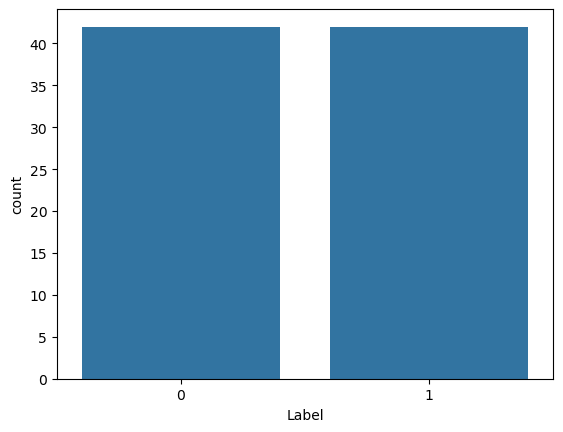

In [23]:
#Understand the data 
#Here we can see that we have a balanced dataset (equal number of flooded and non flooeded locations
sns.countplot(x="Label", data=df) #0 - Notflooded   1 - Flooded

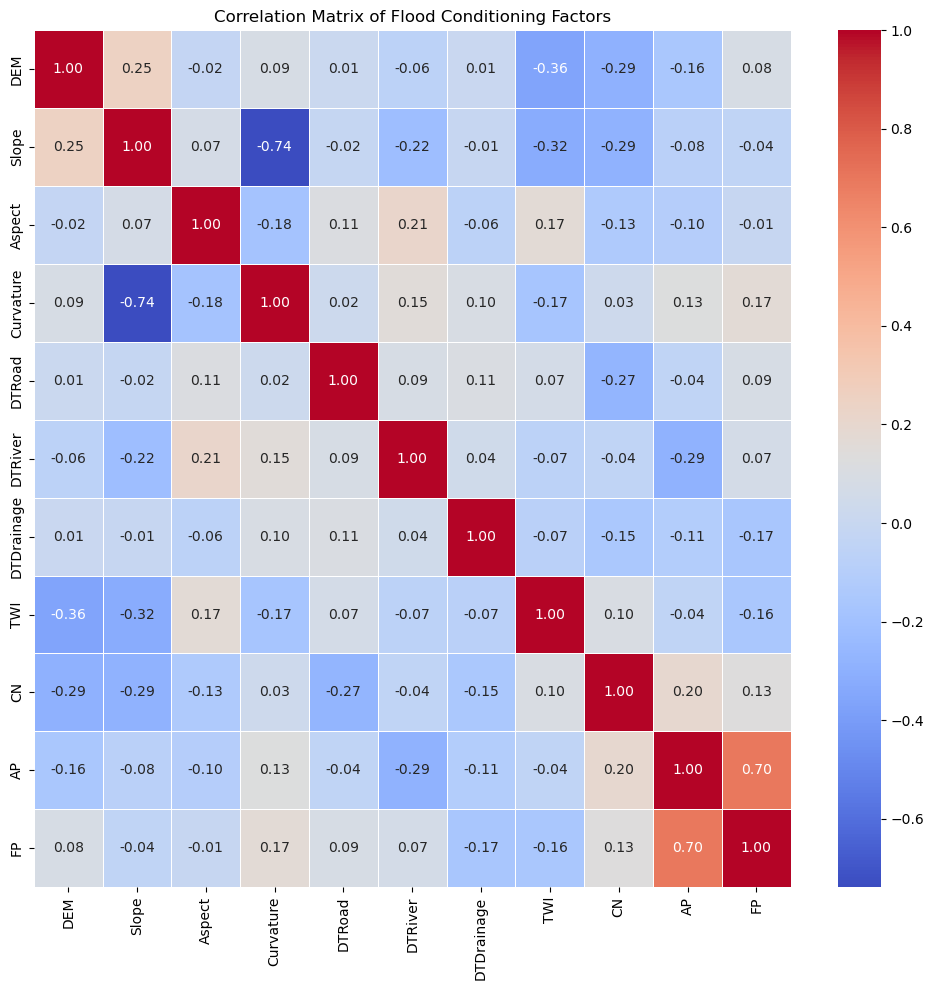

In [24]:
feature_cols = [
    'DEM', 'Slope', 'Aspect', 'Curvature', 'DTRoad',
    'DTRiver', 'DTDrainage', 'TWI', 'CN', 'AP', 'FP'
]

corrMatrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    corrMatrix,
    annot=True,
    linewidths=0.5,
    ax=ax,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Flood Conditioning Factors")
plt.tight_layout()
plt.show()

In [25]:
#Define the dependent variable that needs to be predicted (labels)
Y = df["Label"].values

#Define the independent variables. Let's also drop gemotry and label
X = df.drop(labels = ["Label", "geometry"], axis=1) 
features_list = list(X.columns)  #List features so we can rank their importance later 

In [26]:
#Split data into train (60 %), validate (20 %) and test (20%) to verify accuracy after fitting the model.
# training data is used to train the model
# validation data is used for hyperparameter tuning
# testing data is used to test the model

from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=0.2,shuffle=True, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25,shuffle=True, random_state=42)

In [27]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state = 42) # I am using the default values of the parameters.

# Train the model on training data
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
# make prediction for the test dataset.
prediction = model.predict(X_test)

# The prediction values are either 1 (Flooded) or 0 (Non-Flooded) 
prediction

array([1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0], dtype=int32)

总样本数: 84
测试集样本数: 17
预测概率唯一值数量: 16
预测概率唯一值: [0.09 0.16 0.32 0.35 0.44 0.45 0.48 0.51 0.52 0.55 0.58 0.59 0.61 0.78
 0.8  0.81]


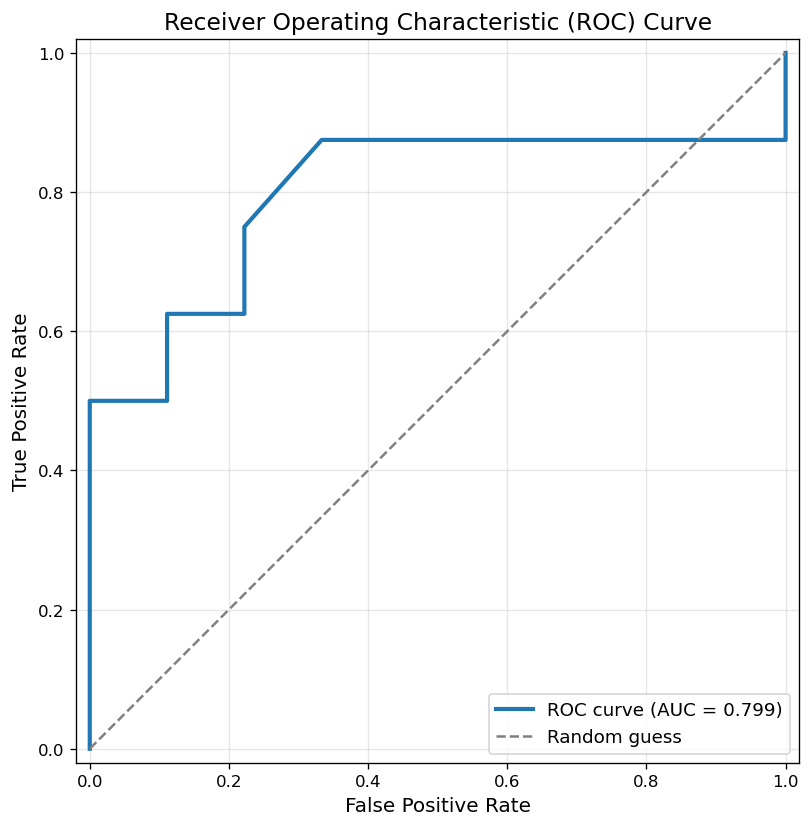

AUC = 0.7986


In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. 获取预测概率
# ===============================

if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(X_test)[:, 1]
elif hasattr(model, "decision_function"):
    y_score = model.decision_function(X_test)
else:
    raise ValueError("当前模型既不支持 predict_proba，也不支持 decision_function，无法绘制标准 ROC 曲线。")


# ===============================
# 2. 计算 ROC 与 AUC
# ===============================

fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
print("总样本数:", len(df))
print("测试集样本数:", len(y_test))
print("预测概率唯一值数量:", len(np.unique(y_score)))
print("预测概率唯一值:", np.unique(y_score))

# ===============================
# 3. 绘制 ROC 曲线
# ===============================

plt.figure(figsize=(7, 7), dpi=120)

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"ROC curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label="Random guess"
)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)

plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

print(f"AUC = {roc_auc:.4f}")

## Map the whole study area

In [36]:
# Read shapefile for the whole study area
df_SA=gpd.read_file("Study_area.shp")
df_SA.head() # make sure that the dataset has the same column arrangement as the training dataset



DataSourceError: Study_area.shp: No such file or directory

In [ ]:
X_SA= df_SA.drop(labels = ["geometry"], axis=1) # we need to remove all the columns except the predictive features
X_SA.head()


In [ ]:
prediction_SA = model.predict(X_SA) # predict if the location is flooded (1) or not flooded (0)



In [ ]:
# In order to map the flood susceptibility we need to cacluate the probability of being flooded
prediction_prob=model.predict_proba(X_SA) # This function return an array with lists 
# each list has two values [probability of being not flooded , probability of being flooded]

# We need only the probablity of being flooded
# We need to add the value coressponding to each point

df_SA['FSM']= prediction_prob[:,1]

In [ ]:
# Save the dataframe tp a shapefile in case of converting the points to raster using QGIS or Arcmap
df_SA.to_file("FSM.shp")

In [ ]:
# Converting the point shapefile to raster.
# We will use the model prediction (column FSM in df_SA to make a raster)
from geocube.api.core import make_geocube
import rasterio as rio

out_grid= make_geocube(vector_data=df_SA, measurements=["FSM"], resolution=(-1, 1)) #for most crs negative comes first in resolution
out_grid["FSM"].rio.to_raster("Flood_susceptibility.tif")